# Trabalho 01 - Apresentação

Análise de dados referente ao inventário de emissões atmosféricas do estado do Paraná de fontes fixas por diversos setores, disponibilizado pelo Instituto Água e Terra

Os dados são dos anos de 2023 e 2024 e o parâmetro escolhido é MPT

Requisitos:
- Operação com dados - leitura e manipulação
- Estatística univariada
- Estatística bivariada


## Importando pacotes, leitura dos arquivos e criação de um único DataFrame


In [397]:
# Automatizando Pacotes
import os
import pandas as pd
import matplotlib.pyplot as plt

#Listando os arquivos dentro da pasta de dados
files = os.listdir(r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\trabalho1")
files = [ fname for fname in files if fname.endswith('.csv')]
files

['Relatorio_Inventario_Completo_MPT_2023.csv',
 'Relatorio_Inventario_Completo_MPT_2024.csv']

In [398]:
# Crio uma lista vazia para juntar os dados de todos os arquivos em um único DataFrame
dfs = []

for file in files:
    print(file)
    # Abre o arquivo
    df_0 = pd.read_csv(r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\trabalho1" + "/" + file)
    # Agora adiciono o DataFrame df na lista dfs que eu criei
    dfs.append(df_0)

# Concatena todos os DataFrames (crio uma outra tabela com todas as informações das 2 tabelas)
df_all = pd.concat(dfs, ignore_index=True)

# Para ter noção do formato da tabela
df_all.dtypes

Relatorio_Inventario_Completo_MPT_2023.csv
Relatorio_Inventario_Completo_MPT_2024.csv


Atividade                      object
Atividade Específica           object
Município                      object
Ano da Declaração               int64
Órgão Emissor                  object
Ponto de Emissão               object
Descrição Ponto de Emissão     object
Latitude                      float64
Longitude                     float64
Origem Emissão                 object
Equipamento                    object
Parâmetro                      object
Combustível                    object
VBS                             int64
Taxa ton/ano                   object
Média taxa ton/ano            float64
dtype: object

## Object para float64

In [399]:
# Converte a coluna 'Taxa ton/ano' para número (para realizarmos os cálculos)
df_all["Taxa ton/ano"] = (df_all["Taxa ton/ano"].astype(str).str.replace(",", ".", regex=False))
# Tenta converter para float — se algo não for número, vira NaN
df_all["Taxa ton/ano"] = pd.to_numeric(df_all["Taxa ton/ano"], errors="coerce")

df_all.head()

,Atividade,Atividade Específica,Município,Ano da Declaração,Órgão Emissor,Ponto de Emissão,Descrição Ponto de Emissão,Latitude,Longitude,Origem Emissão,Equipamento,Parâmetro,Combustível,VBS,Taxa ton/ano,Média taxa ton/ano
0,Ind. da madeira,"Fabricação de chapas, placas de madeira aglome...",Imbituva,2023,IAT,Chaminé,"Chaminé 2 - altura 12,00m / diâmetro 0,55m",-25.239494,-50.588894,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - silo de pó,MPT,NaN,3296,2.94267,2.94267
1,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 2 - altura 2,00m / diâmetro 0,80m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - transport...,MPT,NaN,31115,57.63120,57.63120
2,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 5 - altura 5,00m / diâmetro 1,10m",-25.934047,-53.482794,Exaustão de Material Particulado Total - MPT,Filtro Manga - coladeira de borda,MPT,NaN,50697,118.24568,118.24568
3,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 1 - altura 7,00m / diâmetro 0,8m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - corte,MPT,NaN,21705,43.17993,43.17993
4,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 3 - altura 5,00m / diâmetro 0,50m",-25.934048,-53.482715,Exaustão de Material Particulado Total - MPT,Filtro Manga - corte,MPT,NaN,6717,19.35302,19.35302


In [400]:
df_all.dtypes

Atividade                      object
Atividade Específica           object
Município                      object
Ano da Declaração               int64
Órgão Emissor                  object
Ponto de Emissão               object
Descrição Ponto de Emissão     object
Latitude                      float64
Longitude                     float64
Origem Emissão                 object
Equipamento                    object
Parâmetro                      object
Combustível                    object
VBS                             int64
Taxa ton/ano                  float64
Média taxa ton/ano            float64
dtype: object

## Estatísticas de emissões por setor

In [401]:
# Estatísticas descritivas de emissões (por setor), inclui count, mean, std, min, 25%, 50%, 75%, max
estatisticas_setor = (df_all.groupby('Atividade')['Taxa ton/ano'].describe().round(2)) # arredonda os valores pra 2 casas decimais

estatisticas_setor

,count,mean,std,min,25%,50%,75%,max
Atividade,,,,,,,,
Alimentos,588.0,1154.21,3302.46,0.00,36.87,246.53,1198.95,50041.82
Armazenamento e atividades auxiliares dos transportes,30.0,64.49,70.35,0.00,10.95,39.63,91.89,274.54
Atividades funerárias e serviços relacionados,30.0,26.55,76.04,0.38,2.95,5.77,19.92,415.74
Avicultura,1.0,0.02,NaN,0.02,0.02,0.02,0.02,0.02
Base de distribuição,3.0,3.12,3.91,0.83,0.86,0.90,4.27,7.64
Bebidas,35.0,891.38,1276.19,2.31,8.71,169.34,1148.26,4938.06
Beneficiamento de mandioca,30.0,571.01,1183.83,5.99,31.92,122.93,610.14,5979.37
Beneficiamento de minerais não metálicos,247.0,746.32,2862.61,0.00,25.48,101.38,391.88,36822.30
Beneficiamento e armazenamento de produtos agrícolas,67.0,3179.50,22207.10,1.89,26.18,85.40,273.96,182068.37


## Identificar com boxplot quais setores possuem outlier

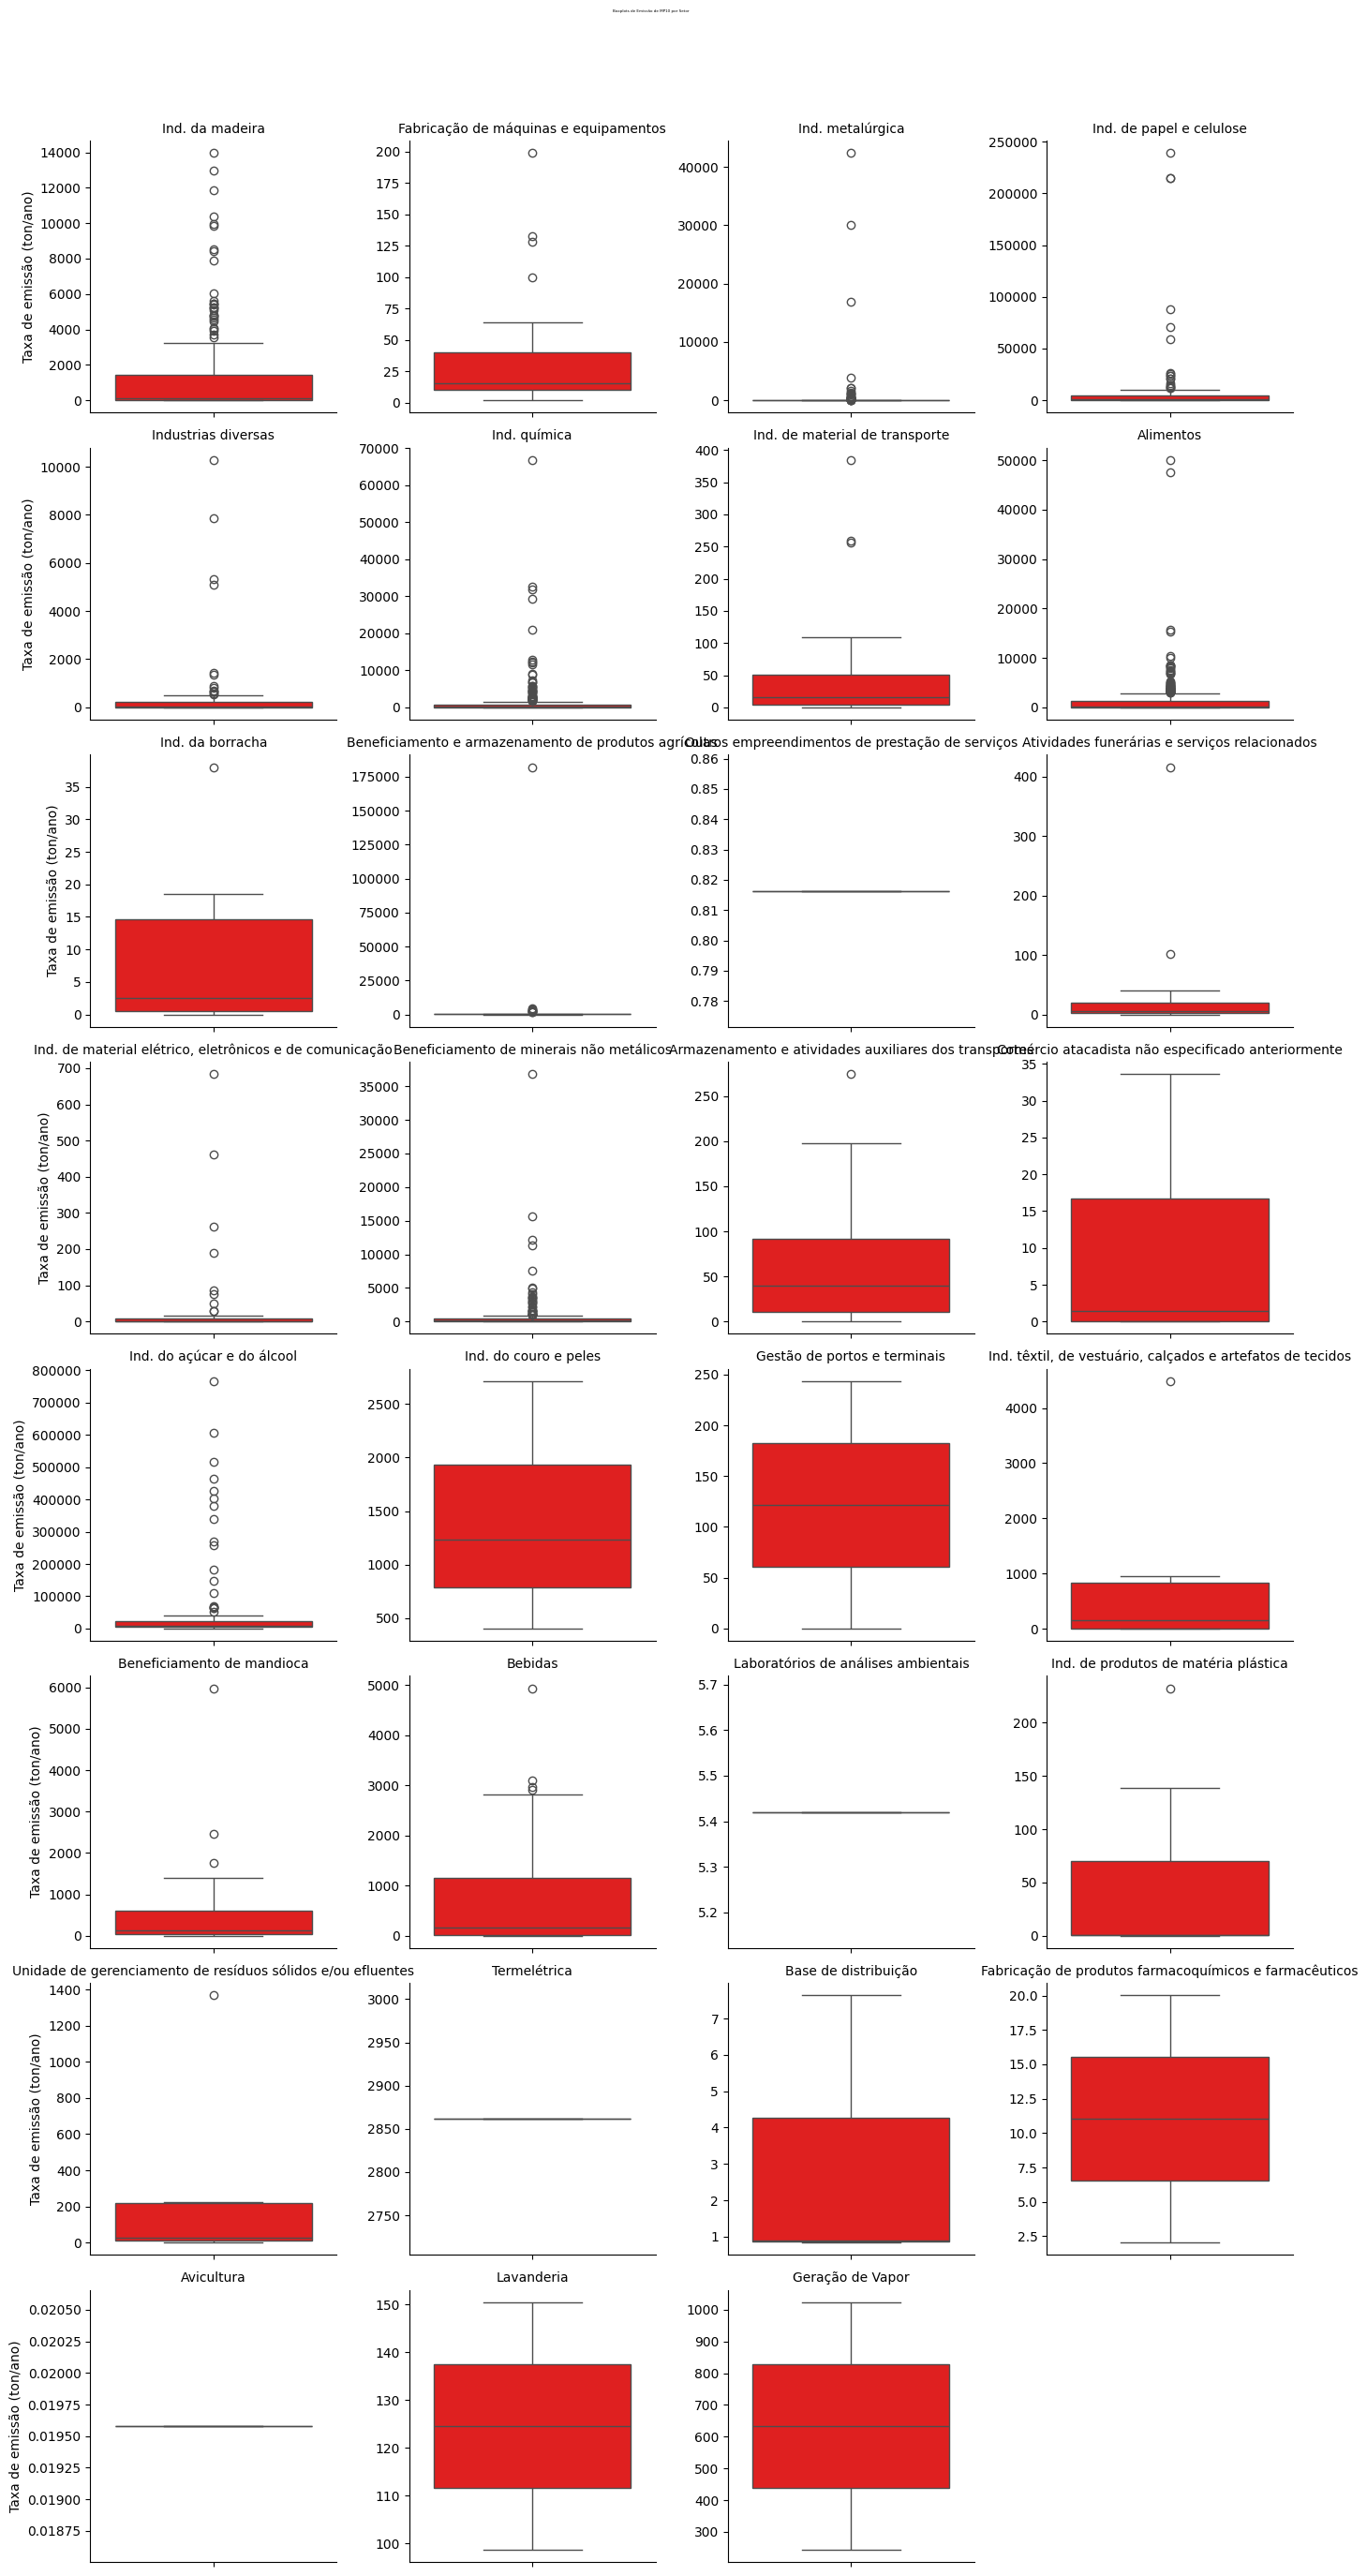

In [402]:
import seaborn as sns

# Filtra colunas e remove dados nulos
df_plot = df_all[['Atividade', 'Taxa ton/ano']].dropna()

# Cria os boxplots por setor
g = sns.FacetGrid(df_plot, col='Atividade', col_wrap=4, height=3.5, sharex=False, sharey=False)
g.map_dataframe(sns.boxplot, y='Taxa ton/ano', color='r')

# Ajustes visuais
g.set_titles(col_template="{col_name}")
g.set_axis_labels('', 'Taxa de emissão (ton/ano)')
plt.subplots_adjust(top=0.93)
g.fig.suptitle('Boxplots de Emissão de MP10 por Setor', fontsize=3)
plt.show()

In [403]:
import numpy as np

# Faz uma cópia pra não alterar o original
df = df_all.copy()

# Remove outliers dentro de cada setor (Atividade)
for setor in df['Atividade'].unique():
    # Calcula o 99.5º percentil dentro do setor
    limite = np.nanpercentile(df.loc[df['Atividade'] == setor, 'Taxa ton/ano'], 99.5)
    # Substitui valores acima do 99.5º percentil por NaN
    df.loc[(df['Atividade'] == setor) & (df['Taxa ton/ano'] >= limite),'Taxa ton/ano'] = np.nan


estatisticas_setor_sem_outlier = (df.groupby('Atividade')['Taxa ton/ano'].describe().round(2))

estatisticas_setor_sem_outlier

,count,mean,std,min,25%,50%,75%,max
Atividade,,,,,,,,
Alimentos,585.0,966.64,1673.04,0.00,36.46,242.61,1188.56,15240.90
Armazenamento e atividades auxiliares dos transportes,29.0,57.24,59.12,0.00,8.52,35.04,84.94,198.08
Atividades funerárias e serviços relacionados,29.0,13.13,19.79,0.38,2.93,5.22,18.45,101.43
Avicultura,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base de distribuição,2.0,0.86,0.04,0.83,0.85,0.86,0.88,0.90
Bebidas,34.0,772.36,1080.36,2.31,8.54,167.23,1059.50,3101.82
Beneficiamento de mandioca,29.0,384.51,608.96,5.99,31.37,112.71,402.86,2458.39
Beneficiamento de minerais não metálicos,245.0,538.05,1402.91,0.00,25.38,101.37,364.53,12177.20
Beneficiamento e armazenamento de produtos agrícolas,66.0,469.06,977.79,1.89,23.65,84.43,264.44,4770.15


## Comparação Geral de Emissão nos anos de 2023 e 2024

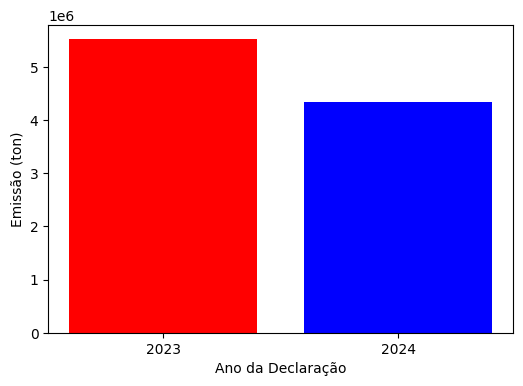

In [404]:
# Agrupa pelos valores da coluna 'Ano da Declaração'
df_grouped = df_all.groupby("Ano da Declaração")["Taxa ton/ano"].sum().reset_index()

# Cria o gráfico de barras comparando os anos
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_grouped["Ano da Declaração"], df_grouped["Taxa ton/ano"], color=['r', 'b'])

# Personalizações
ax.set_xlabel("Ano da Declaração")
ax.set_ylabel("Emissão (ton)")
ax.set_xticks(df_grouped["Ano da Declaração"])

# Salva o gráfico
fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\comparativo_taxa_cada_ano.png")

## Percentil médio de emissão por setor

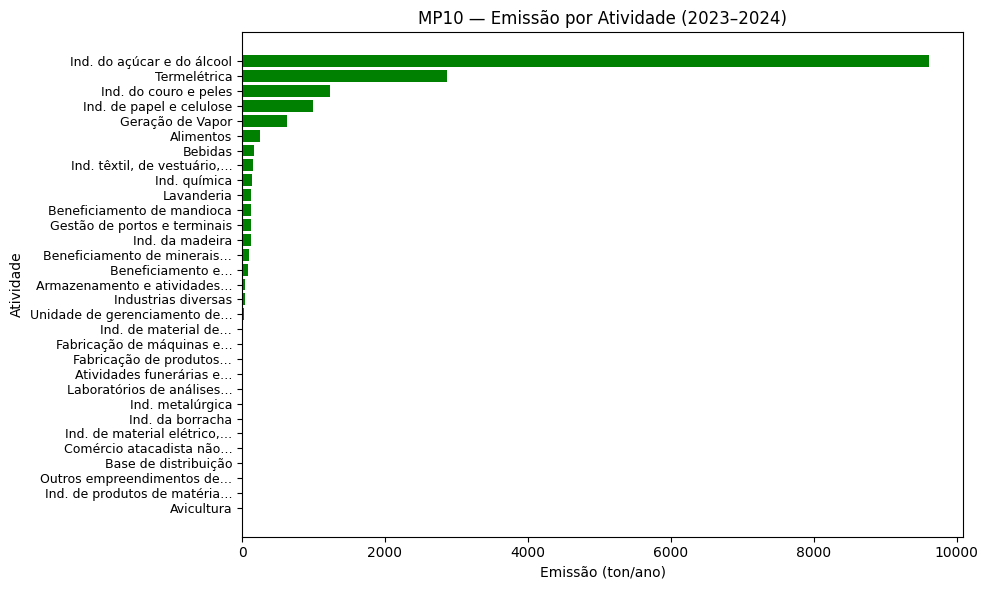

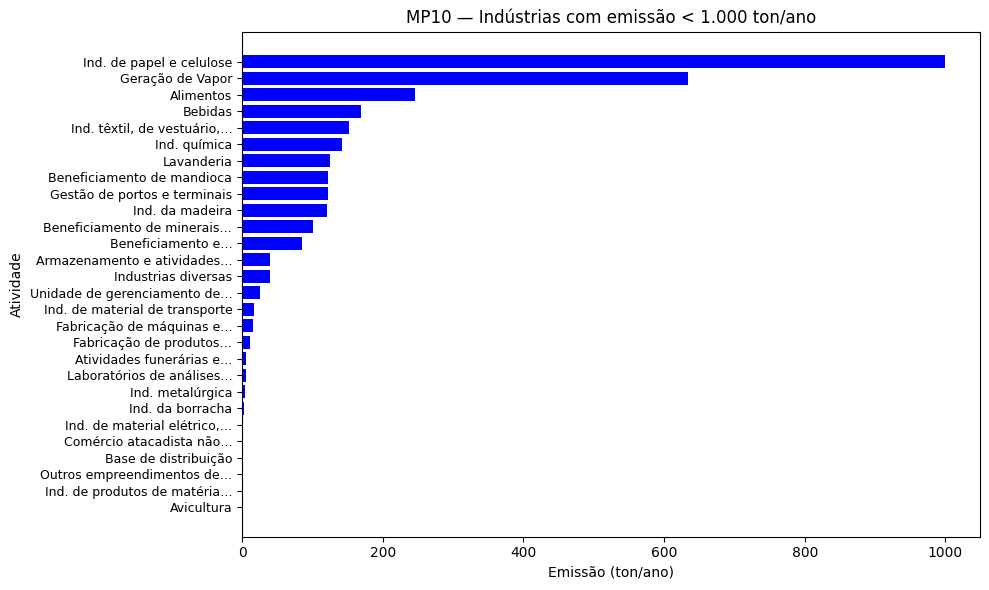

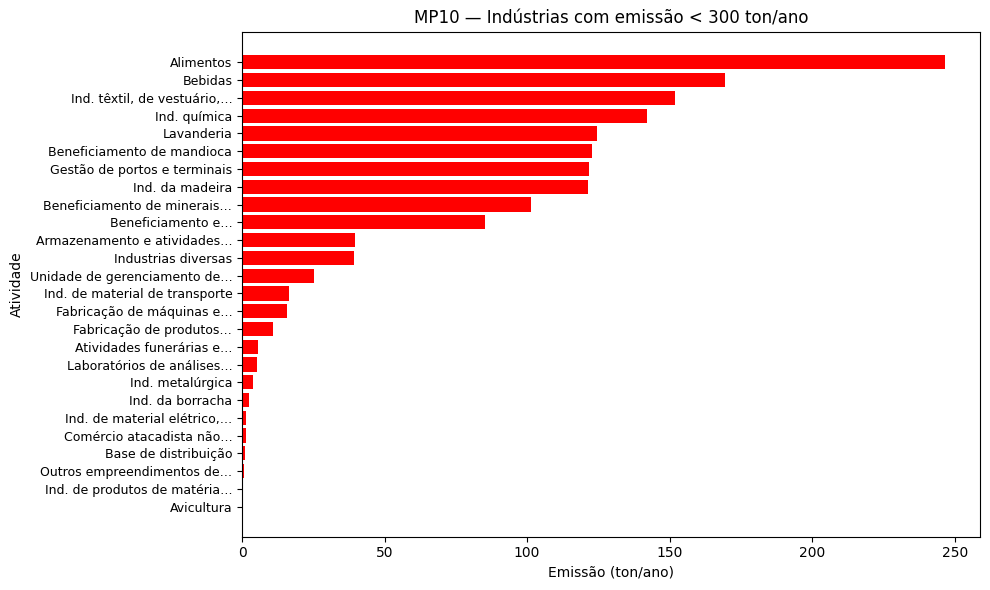

In [423]:
# MÉDIA DE EMISSÃO POR ATIVIDADE (GERAL, 2023–2024 juntos)

# garante que só use as colunas necessárias e tira Atividade nula
df_tmp = df_all[['Atividade', 'Taxa ton/ano']].copy()
df_tmp = df_tmp.dropna(subset=['Atividade'])

# Agrupa os setores, usa "as_index' para resultado voltar como DataFrame, fazemos a emissão média de cada atividade,
# Troquei o nome da coluna para facilitar entendimento, ".sort_values" ordena do maior para o menor.
media_por_atividade = (df_tmp.groupby('Atividade', as_index=False)['Taxa ton/ano'].median().rename\
(columns={'Taxa ton/ano': 'Emissão (ton/ano)'}).sort_values('Emissão (ton/ano)', ascending=False))

# Encurtar o nome dos setores
from textwrap import shorten
labels = media_por_atividade['Atividade'].astype(str).apply(lambda s: shorten(s, width=28, placeholder='…'))

# Gráfico com todas as atividades
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(labels.iloc[::-1], media_por_atividade['Emissão (ton/ano)'][::-1], color='g')
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.set_title('MP10 — Emissão por Atividade (2023–2024)')
ax.tick_params(axis='y', labelsize=9)  
fig.subplots_adjust(left=0.32)          
fig.tight_layout()

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor.png")

# Gráfico com apenas atividades "médias"
filtro = media_por_atividade[media_por_atividade['Emissão (ton/ano)'] < 1000].copy()
# Encurta os nomes das atividades
labels = filtro['Atividade'].astype(str).apply(lambda s: shorten(s, width=30, placeholder='…'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], filtro['Emissão (ton/ano)'][::-1], color='b')
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.set_title('MP10 — Indústrias com emissão < 1.000 ton/ano')
ax.tick_params(axis='y', labelsize=9)
fig.subplots_adjust(left=0.33)  
fig.tight_layout()

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor_mediano.png")


# Gráfico com apenas atividades pequenas
filtro = media_por_atividade[media_por_atividade['Emissão (ton/ano)'] < 300].copy()
labels = filtro['Atividade'].astype(str).apply(lambda s: shorten(s, width=30, placeholder='…'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], filtro['Emissão (ton/ano)'][::-1], color='r')
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.set_title('MP10 — Indústrias com emissão < 300 ton/ano')
ax.tick_params(axis='y', labelsize=9)
fig.subplots_adjust(left=0.33)
fig.tight_layout()


fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor_pequeno.png")

## Percentil médio por Atividade em cada ano

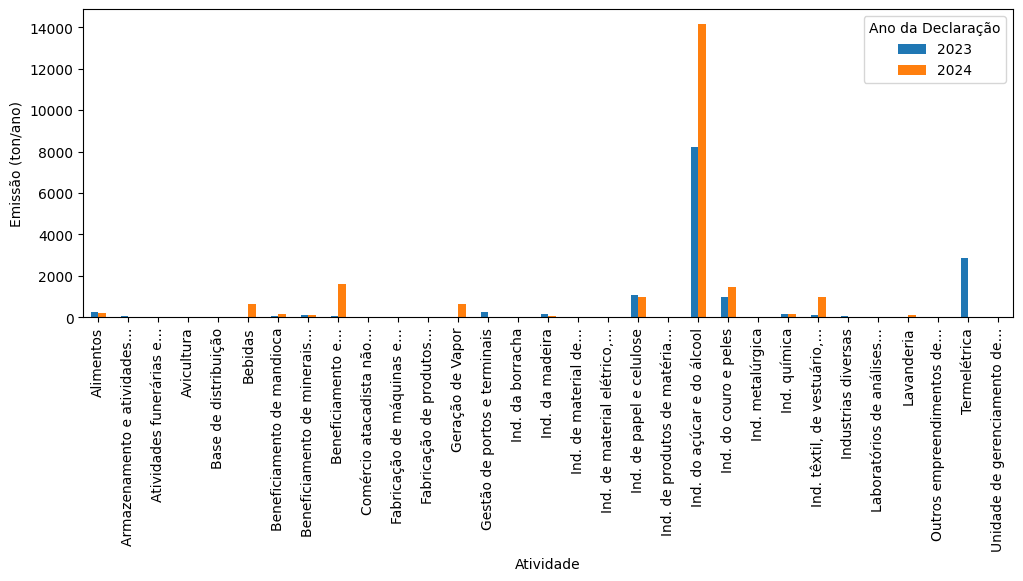

In [440]:
# MÉDIA POR ATIVIDADE EM CADA ANO (2023 vs 2024)

media_ano_atividade = (df_all.groupby(['Ano da Declaração', 'Atividade'], as_index=False)\
['Taxa ton/ano'].median().rename(columns={'Taxa ton/ano': 'Emissão média (ton/ano)'}))

from textwrap import shorten
# Encurta apenas os textos dentro da coluna 'Atividade'
media_ano_atividade['Atividade'] = media_ano_atividade['Atividade'].astype(str).apply(lambda s: shorten(s, width=28, placeholder='…'))
    
# Tabela comparativa lado a lado (todas as atividades)
# pivot(Atividade vira índice, coluna separada pra cada ano, conteúdo das células é a emissão média
comparativo = (media_ano_atividade.pivot(index='Atividade', columns='Ano da Declaração'\
, values='Emissão média (ton/ano)').fillna(0)) # NaN = 0 

# Gráfico com todas as atividades
fig, ax = plt.subplots(figsize=(12, 4))
comparativo.plot(kind='bar', ax=ax)
ax.set_xlabel('Atividade')
ax.set_ylabel('Emissão (ton/ano)')
ax.legend(title='Ano da Declaração')

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor_comparativo_anos.png", bbox_inches='tight', pad_inches=0.2,dpi=300)

## Emissão por tipo de ponto de emissão 

In [409]:
# quero identificar quantos tipos de 'Ponto de Emissão' e 'Descrição de Ponto de Emissão para ver como vou fazer minha análise
print(df_all['Descrição Ponto de Emissão'].nunique())
print(df_all['Ponto de Emissão'].nunique())
df.head()

1031
2


,Atividade,Atividade Específica,Município,Ano da Declaração,Órgão Emissor,Ponto de Emissão,Descrição Ponto de Emissão,Latitude,Longitude,Origem Emissão,Equipamento,Parâmetro,Combustível,VBS,Taxa ton/ano,Média taxa ton/ano
0,Ind. da madeira,"Fabricação de chapas, placas de madeira aglome...",Imbituva,2023,IAT,Chaminé,"Chaminé 2 - altura 12,00m / diâmetro 0,55m",-25.239494,-50.588894,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - silo de pó,MPT,NaN,3296,2.94267,2.94267
1,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 2 - altura 2,00m / diâmetro 0,80m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - transport...,MPT,NaN,31115,57.63120,57.63120
2,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 5 - altura 5,00m / diâmetro 1,10m",-25.934047,-53.482794,Exaustão de Material Particulado Total - MPT,Filtro Manga - coladeira de borda,MPT,NaN,50697,118.24568,118.24568
3,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 1 - altura 7,00m / diâmetro 0,8m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - corte,MPT,NaN,21705,43.17993,43.17993
4,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 3 - altura 5,00m / diâmetro 0,50m",-25.934048,-53.482715,Exaustão de Material Particulado Total - MPT,Filtro Manga - corte,MPT,NaN,6717,19.35302,19.35302


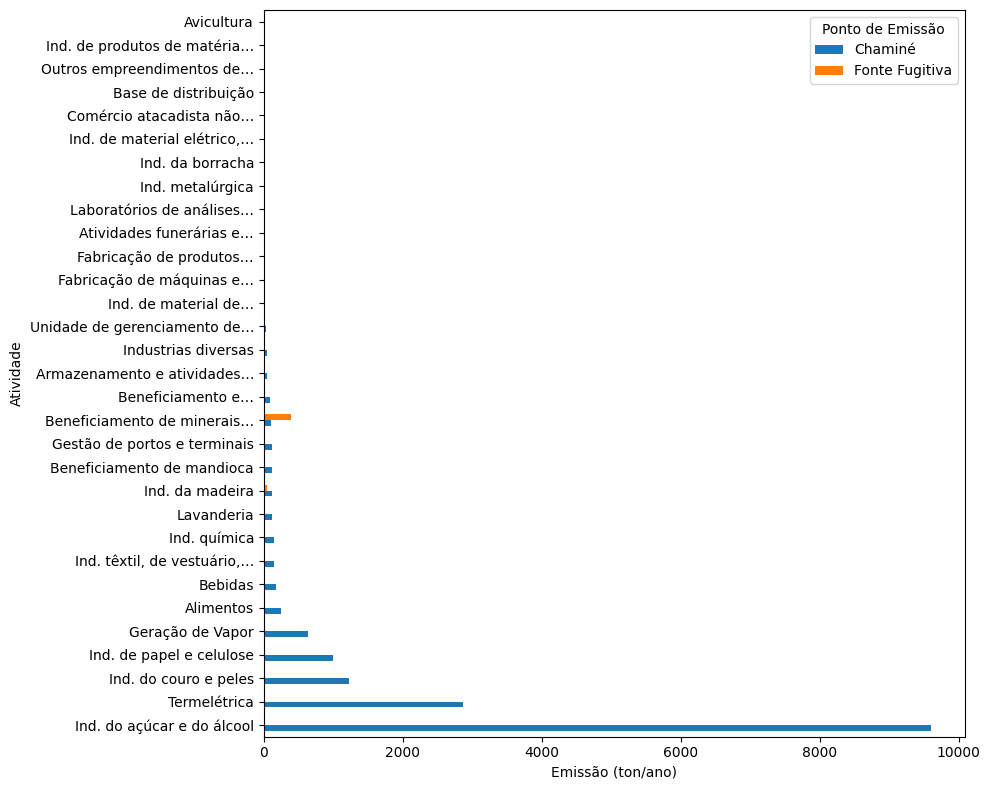

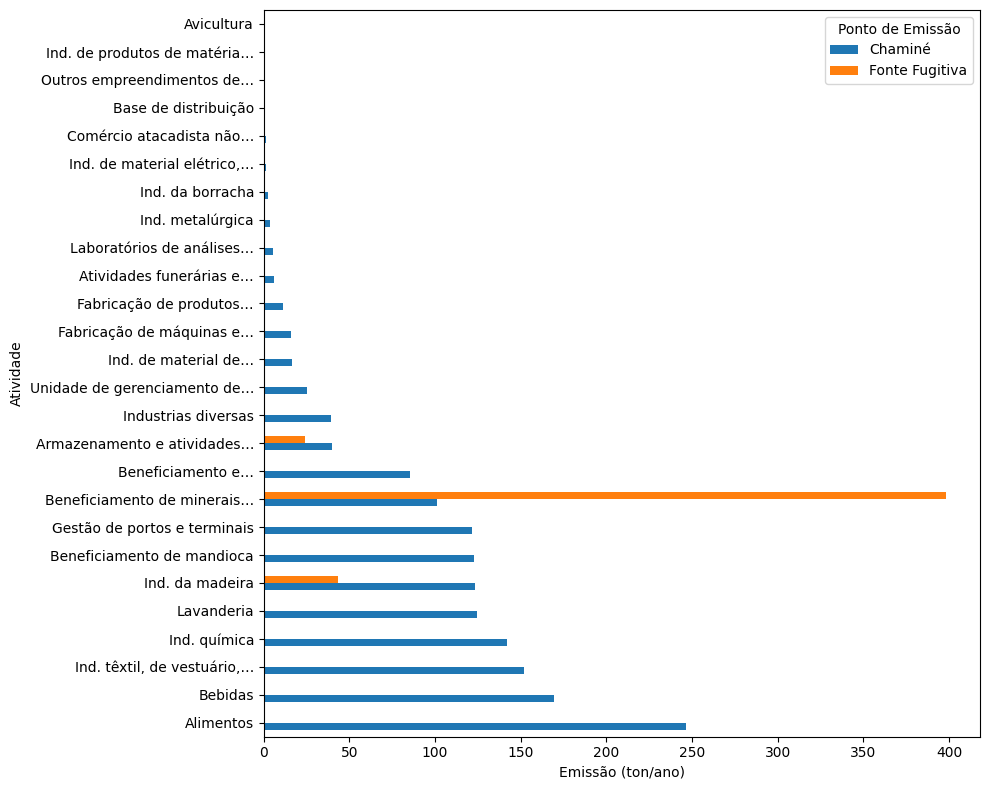

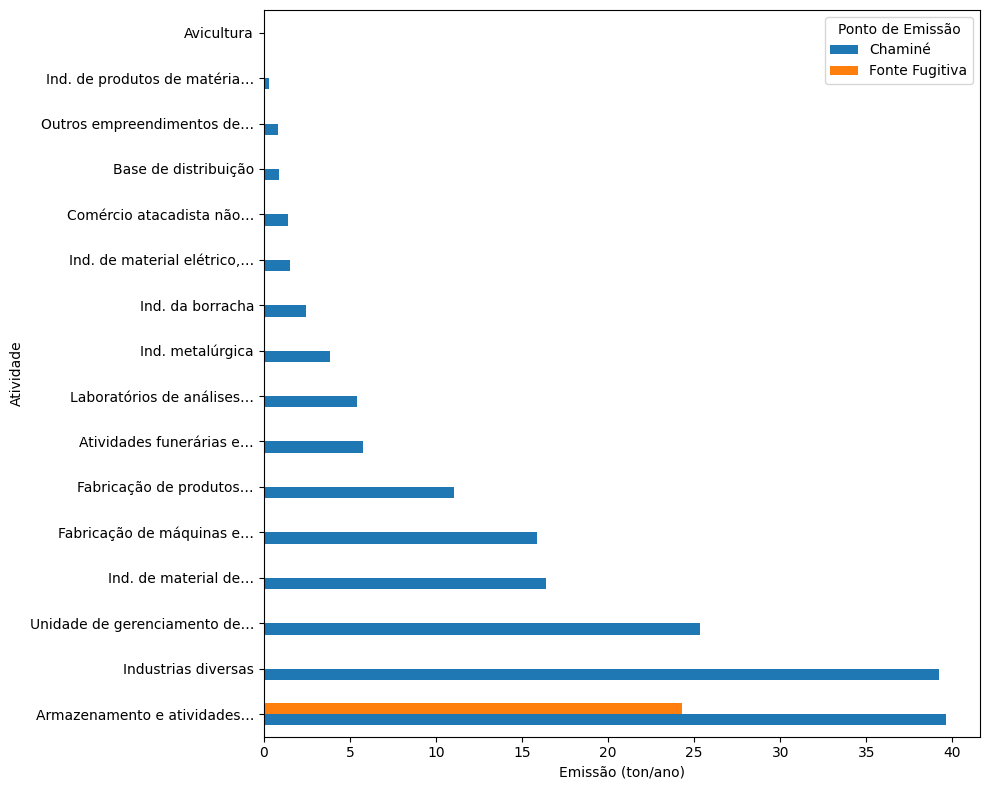

In [442]:
# EMISSÃO POR PONTO DE EMISSÃO E ANO 

emissao_ponto_por_atividade = (df_all.groupby(['Atividade', 'Ponto de Emissão'], as_index=False)\
['Taxa ton/ano'].median().rename(columns={'Taxa ton/ano': 'Emissão mediana (ton/ano)'}))

from textwrap import shorten
# Encurta apenas os textos dentro da coluna 'Atividade'
emissao_ponto_por_atividade['Atividade'] = emissao_ponto_por_atividade['Atividade'].astype(str).apply(lambda s: shorten(s, width=28, placeholder='…'))

# Transforma o resultado em formato de tabela larga (anos nas linhas, pontos nas colunas)
tabela_atividade = (emissao_ponto_por_atividade.pivot(index='Atividade', columns='Ponto de Emissão',\
values='Emissão mediana (ton/ano)').fillna(0)).sort_values(by=tabela_atividade.columns[0], ascending=False)

# GRÁFICO — BARRAS LADO A LADO 
fig, ax = plt.subplots(figsize=(10, 8))
tabela_atividade.plot(kind='barh', ax=ax)
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.legend(title='Ponto de Emissão')
plt.tight_layout()
fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_ponto.png")

tabela_filtrada = tabela_atividade[tabela_atividade.max(axis=1) < 400]
fig, ax = plt.subplots(figsize=(10, 8))
tabela_filtrada.plot(kind='barh', ax=ax)
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.legend(title='Ponto de Emissão')
plt.tight_layout()

tabela_filtrada2 = tabela_atividade[tabela_atividade.max(axis=1) < 50]
fig, ax = plt.subplots(figsize=(10, 8))
tabela_filtrada2.plot(kind='barh', ax=ax)
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.legend(title='Ponto de Emissão')
plt.tight_layout()

## Relação da Altura da chaminé de cada setor e sua emissão

In [411]:
df_all[['Chaminé', 'Altura (m)', 'Diâmetro (m)']] = df_all['Descrição Ponto de Emissão'].str.\
extract(r'Chaminé\s*(\d+)\s*-\s*altura\s*([\d,]+)m\s*/\s*diâmetro\s*([\d,]+)m',expand=True)

# Substitui vírgulas por pontos e converte para float
df_all['Altura (m)'] = df_all['Altura (m)'].str.replace(',', '.').astype(float)
df_all['Diâmetro (m)'] = df_all['Diâmetro (m)'].str.replace(',', '.').astype(float)

df_chamine = df_all[['Descrição Ponto de Emissão','Chaminé', 'Altura (m)', 'Diâmetro (m)']]
print(df_chamine.dtypes)
df_chamine

Descrição Ponto de Emissão     object
Chaminé                        object
Altura (m)                    float64
Diâmetro (m)                  float64
dtype: object


,Descrição Ponto de Emissão,Chaminé,Altura (m),Diâmetro (m)
0,"Chaminé 2 - altura 12,00m / diâmetro 0,55m",2,12.0,0.55
1,"Chaminé 2 - altura 2,00m / diâmetro 0,80m",2,2.0,0.80
2,"Chaminé 5 - altura 5,00m / diâmetro 1,10m",5,5.0,1.10
3,"Chaminé 1 - altura 7,00m / diâmetro 0,8m",1,7.0,0.80
4,"Chaminé 3 - altura 5,00m / diâmetro 0,50m",3,5.0,0.50
...,...,...,...,...
2614,"Chaminé 4 - altura 16,00m / diâmetro 1,10m",4,16.0,1.10
2615,"Chaminé 4 - altura 16,00m / diâmetro 1,10m",4,16.0,1.10
2616,"Chaminé 1 - altura 12,00m / diâmetro 0,50m",1,12.0,0.50
2617,"Chaminé 1 - altura 12,00m / diâmetro 0,50m",1,12.0,0.50


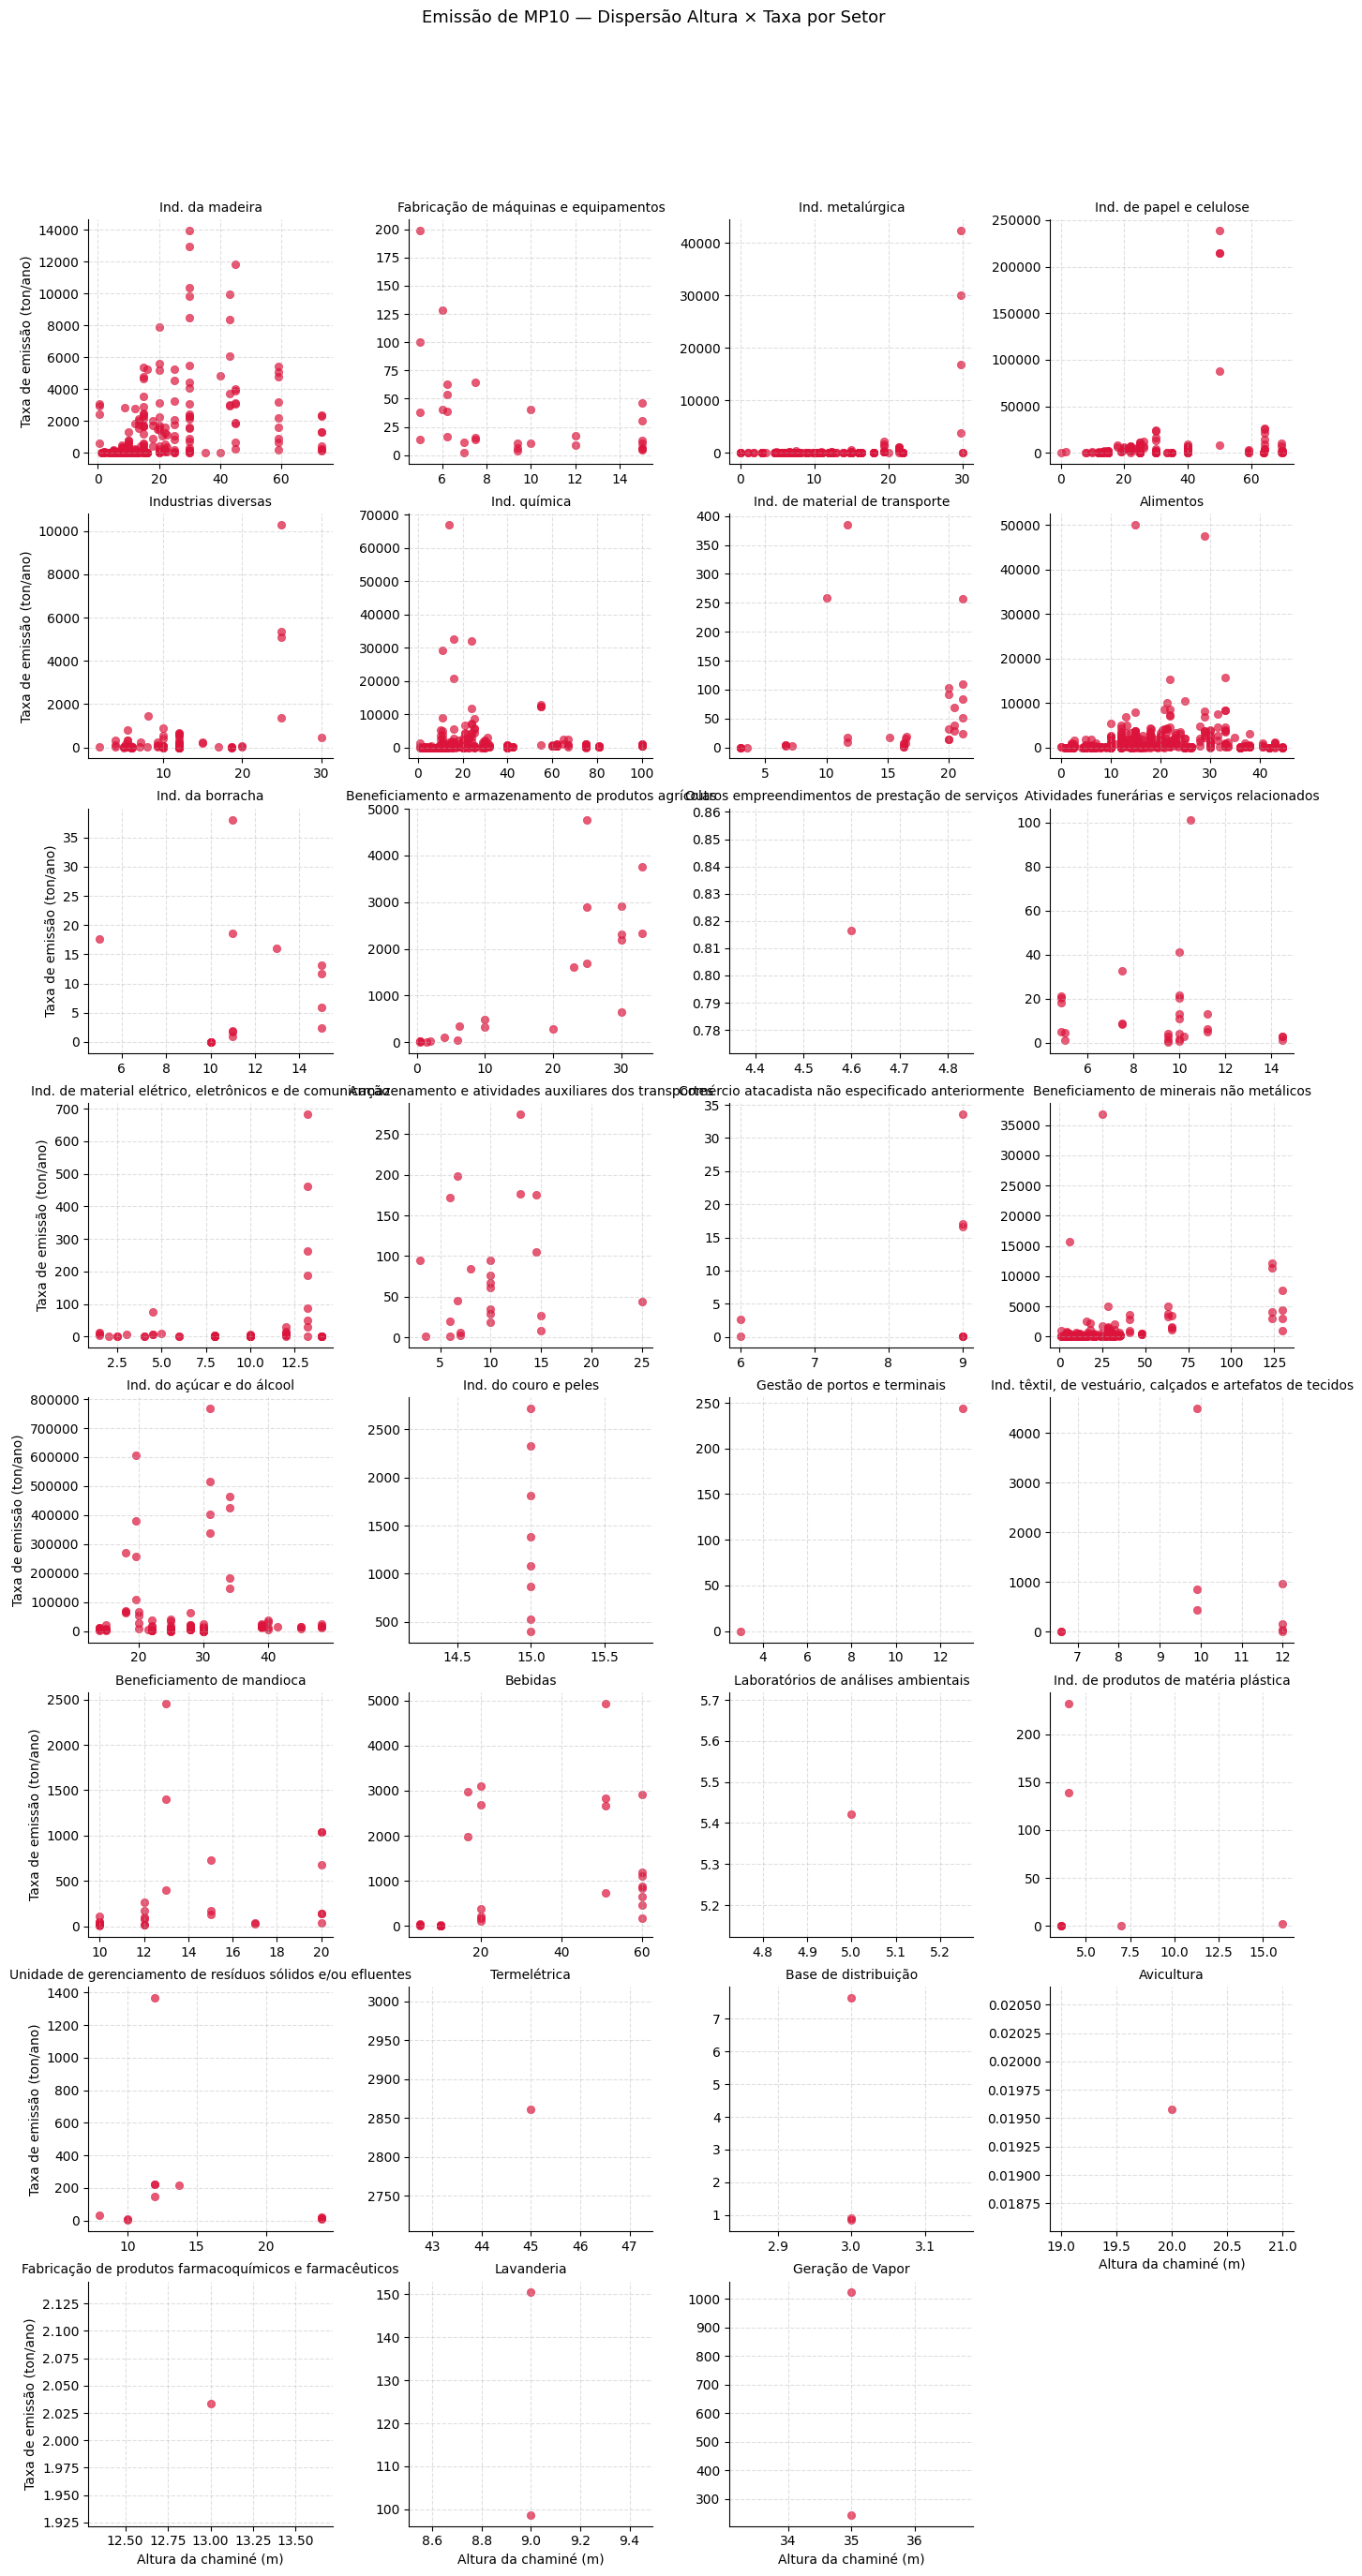

In [412]:
import re
import seaborn as sns
import matplotlib.pyplot as plt

# Prepara os dados (pega Altura da descrição) 
df_plot = df_all[['Atividade', 'Taxa ton/ano', 'Descrição Ponto de Emissão']].copy()
df_plot['Altura (m)'] = (df_plot['Descrição Ponto de Emissão'].str.extract(r'altura\s*([0-9.,]+)\s*m', flags=re.\
IGNORECASE)[0].str.replace(',', '.', regex=False).astype(float))

# mantém apenas linhas com altura e taxa válidas
df_plot = df_plot.dropna(subset=['Altura (m)', 'Taxa ton/ano'])

# Gráficos -  um subplot por setor 
g = sns.FacetGrid(df_plot, col='Atividade', col_wrap=4, height=3.5, sharex=False,sharey=False)
g.map_dataframe(sns.scatterplot, x='Altura (m)', y='Taxa ton/ano', color='crimson', alpha=0.7, edgecolor=None)

# Ajustes visuais 
g.set_titles(col_template="{col_name}")
g.set_axis_labels('Altura da chaminé (m)', 'Taxa de emissão (ton/ano)')
g.fig.subplots_adjust(top=0.90)
g.fig.suptitle('Emissão de MP10 — Dispersão Altura × Taxa por Setor', fontsize=13)

# grade 
for ax in g.axes.flat:
    ax.grid(True, axis='both', linestyle='--', alpha=0.4)

plt.show()